# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from datasets import load_dataset
from tqdm import tqdm
import random
import math
import copy
import time
import gc
from tqdm.auto import tqdm

from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
SEED = 42

def set_seed(seed=SEED):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
      torch.cuda.manual_seed(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# Part 1

In [3]:
ds = load_dataset("flwrlabs/femnist")

full_data = ds["train"]

full_data = full_data.shuffle(seed=SEED)

print("Total number of samples in full FEMNIST dataset:", len(full_data))
print("Dataset columns:", full_data.column_names)

print("\nOne sample:")
print(full_data[0])


07/27/2026 20:22:00:WARNING:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Total number of samples in full FEMNIST dataset: 814277
Dataset columns: ['image', 'writer_id', 'hsf_id', 'character']

One sample:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x271164A4910>, 'writer_id': 'f1971_12', 'hsf_id': 3, 'character': 5}


Total images: 814277
Number of classes: 62
Number of subjects/writers: 3597
Min images per subject: 18
Max images per subject: 583
Mean images per subject: 226.38
Median images per subject: 178.0


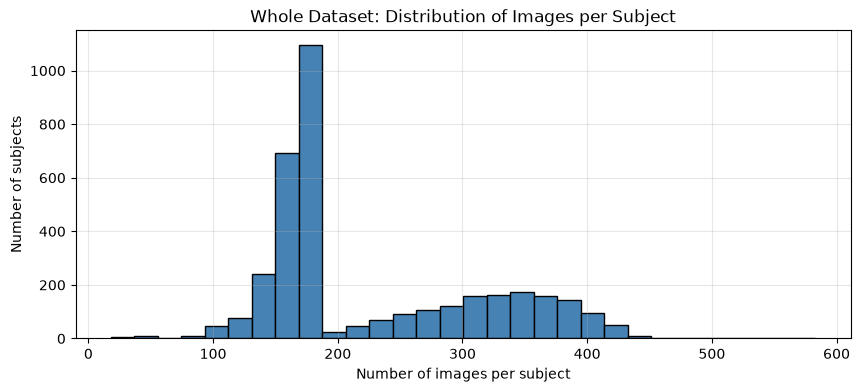

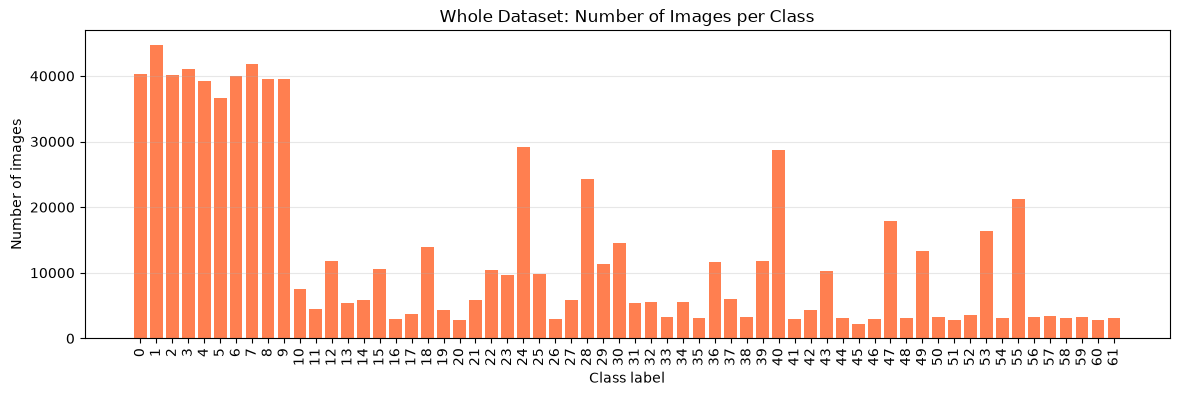

In [4]:
all_writers = full_data["writer_id"]
all_labels = full_data["character"]

unique_writers = sorted(list(set(all_writers)))
unique_labels = sorted(list(set(all_labels)))

writer_counts = Counter(all_writers)
label_counts = Counter(all_labels)

print("Total images:", len(full_data))
print("Number of classes:", len(unique_labels))
print("Number of subjects/writers:", len(unique_writers))

print("Min images per subject:", min(writer_counts.values()))
print("Max images per subject:", max(writer_counts.values()))
print("Mean images per subject:", round(np.mean(list(writer_counts.values())), 2))
print("Median images per subject:", round(np.median(list(writer_counts.values())), 2))

writer_stats_df = pd.DataFrame({
    "writer_id": list(writer_counts.keys()),
    "num_images": list(writer_counts.values())
}).sort_values("num_images", ascending=False).reset_index(drop=True)

label_stats_df = pd.DataFrame({
    "class_label": list(label_counts.keys()),
    "num_images": list(label_counts.values())
}).sort_values("class_label").reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.hist(writer_stats_df["num_images"], bins=30, color="steelblue", edgecolor="black")
plt.title("Whole Dataset: Distribution of Images per Subject")
plt.xlabel("Number of images per subject")
plt.ylabel("Number of subjects")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.bar(label_stats_df["class_label"].astype(str), label_stats_df["num_images"], color="coral")
plt.title("Whole Dataset: Number of Images per Class")
plt.xlabel("Class label")
plt.ylabel("Number of images")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.show()


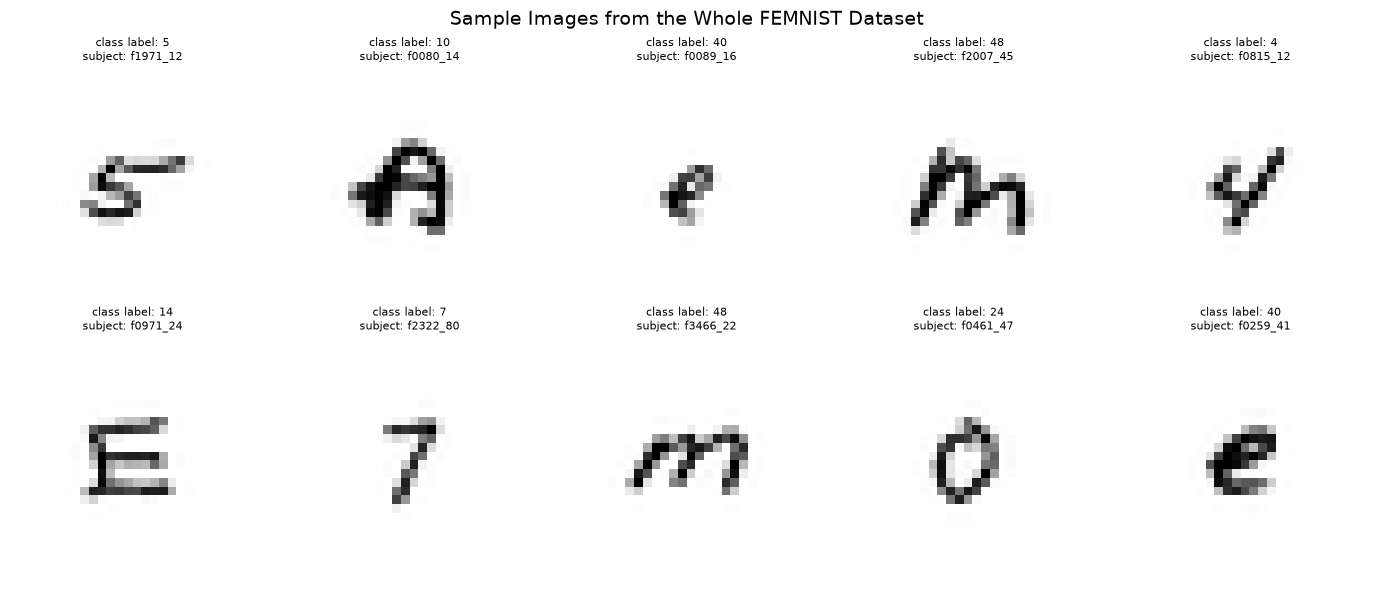

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    item = full_data[i]
    img = np.array(item["image"])

    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"class label: {item['character']}\nsubject: {item['writer_id']}",
        fontsize=8
    )
    ax.axis("off")

plt.suptitle("Sample Images from the Whole FEMNIST Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
set_seed(SEED)
all_subjects = unique_writers.copy()

rng_split = np.random.default_rng(SEED)
rng_split.shuffle(all_subjects)

member_ratio = 0.70

split_point = int(member_ratio * len(all_subjects))

member_subjects = set(all_subjects[:split_point])
non_member_subjects = set(all_subjects[split_point:])

member_indices = []
non_member_indices = []

for idx, writer in enumerate(full_data["writer_id"]):
    if writer in member_subjects:
        member_indices.append(idx)
    else:
        non_member_indices.append(idx)

print("SUBJECT-LEVEL MEMBER / NON-MEMBER SPLIT")
print("Total subjects:", len(all_subjects))
print("Member subjects:", len(member_subjects))
print("Non-member subjects:", len(non_member_subjects))

print("\nTotal images:", len(full_data))
print("Member images:", len(member_indices))
print("Non-member images:", len(non_member_indices))

print("\nMember image percent:", round(100 * len(member_indices) / len(full_data), 2), "%")
print("Non-member image percent:", round(100 * len(non_member_indices) / len(full_data), 2), "%")

overlap = member_subjects.intersection(non_member_subjects)

print("\nOverlap between member and non-member subjects:", len(overlap))
print("Total images after split:", len(member_indices) + len(non_member_indices))


SUBJECT-LEVEL MEMBER / NON-MEMBER SPLIT
Total subjects: 3597
Member subjects: 2517
Non-member subjects: 1080

Total images: 814277
Member images: 569214
Non-member images: 245063

Member image percent: 69.9 %
Non-member image percent: 30.1 %

Overlap between member and non-member subjects: 0
Total images after split: 814277


In [7]:
set_seed(SEED)
NUM_SILOS = 8

writer_to_indices = defaultdict(list)

for idx in member_indices:
    writer = full_data[idx]["writer_id"]
    writer_to_indices[writer].append(idx)

silo_data = defaultdict(list)

rng_silo = np.random.default_rng(SEED + 1)

for writer, idxs in tqdm(writer_to_indices.items(), desc="Assigning member subjects to silos"):
    idxs = np.array(idxs)

    num_silos_for_writer = rng_silo.integers(1, 4)

    chosen_silos = rng_silo.choice(NUM_SILOS, size=num_silos_for_writer, replace=False)

    chunks = np.array_split(idxs, num_silos_for_writer)

    for silo_id, chunk in zip(chosen_silos, chunks):
        silo_data[int(silo_id)].extend(chunk.tolist())

federated_train_indices = []

for s in range(NUM_SILOS):
    federated_train_indices.extend(silo_data[s])

unique_federated_train_indices = sorted(list(set(federated_train_indices)))

for s in range(NUM_SILOS):
    print(f"Silo {s}: {len(silo_data[s])} images")

total_silo_images = sum(len(silo_data[s]) for s in range(NUM_SILOS))

print("\nTotal member images:", len(member_indices))
print("Total images assigned to silos:", total_silo_images)
print("Unique federated training images:", len(unique_federated_train_indices))
print("Total non-member images used in federated training: 0")

leakage_count = 0

for idx in unique_federated_train_indices:
    writer = full_data[idx]["writer_id"]
    if writer in non_member_subjects:
        leakage_count += 1

all_training_from_members = all(
    full_data[idx]["writer_id"] in member_subjects
    for idx in unique_federated_train_indices
)

empty_silos = [s for s in range(NUM_SILOS) if len(silo_data[s]) == 0]

print("\nNon-member leakage count:", leakage_count)
print("All federated training images are from member subjects:", all_training_from_members)
print("Empty silos:", empty_silos)

federated_train_indices = unique_federated_train_indices


Assigning member subjects to silos:   0%|          | 0/2517 [00:00<?, ?it/s]

Silo 0: 75943 images
Silo 1: 72729 images
Silo 2: 70617 images
Silo 3: 65796 images
Silo 4: 71991 images
Silo 5: 68595 images
Silo 6: 72323 images
Silo 7: 71220 images

Total member images: 569214
Total images assigned to silos: 569214
Unique federated training images: 569214
Total non-member images used in federated training: 0

Non-member leakage count: 0
All federated training images are from member subjects: True
Empty silos: []


MEMBER / NON-MEMBER SUMMARY


,group,num_subjects,num_images,image_percent
0,Member,2517,569214,69.904222
1,Non-Member,1080,245063,30.095778


MEMBER IMAGES PER SUBJECT
Min: 18
Max: 464
Mean: 226.15
Median: 178.0

NON-MEMBER IMAGES PER SUBJECT
Min: 39
Max: 583
Mean: 226.91
Median: 178.0


,silo,num_images,share_percent
0,0,75943,13.341731
1,1,72729,12.777093
2,2,70617,12.406055
3,3,65796,11.559097
4,4,71991,12.647440
5,5,68595,12.050828
6,6,72323,12.705766
7,7,71220,12.511990



Total member subjects in silos: 2517
Average number of silos per subject: 2.03
Subjects in exactly 1 silo: 806
Subjects in exactly 2 silos: 825
Subjects in exactly 3 silos: 886
Percent of subjects in one silo: 32.02 %
Percent of subjects in multiple silos: 67.98 %


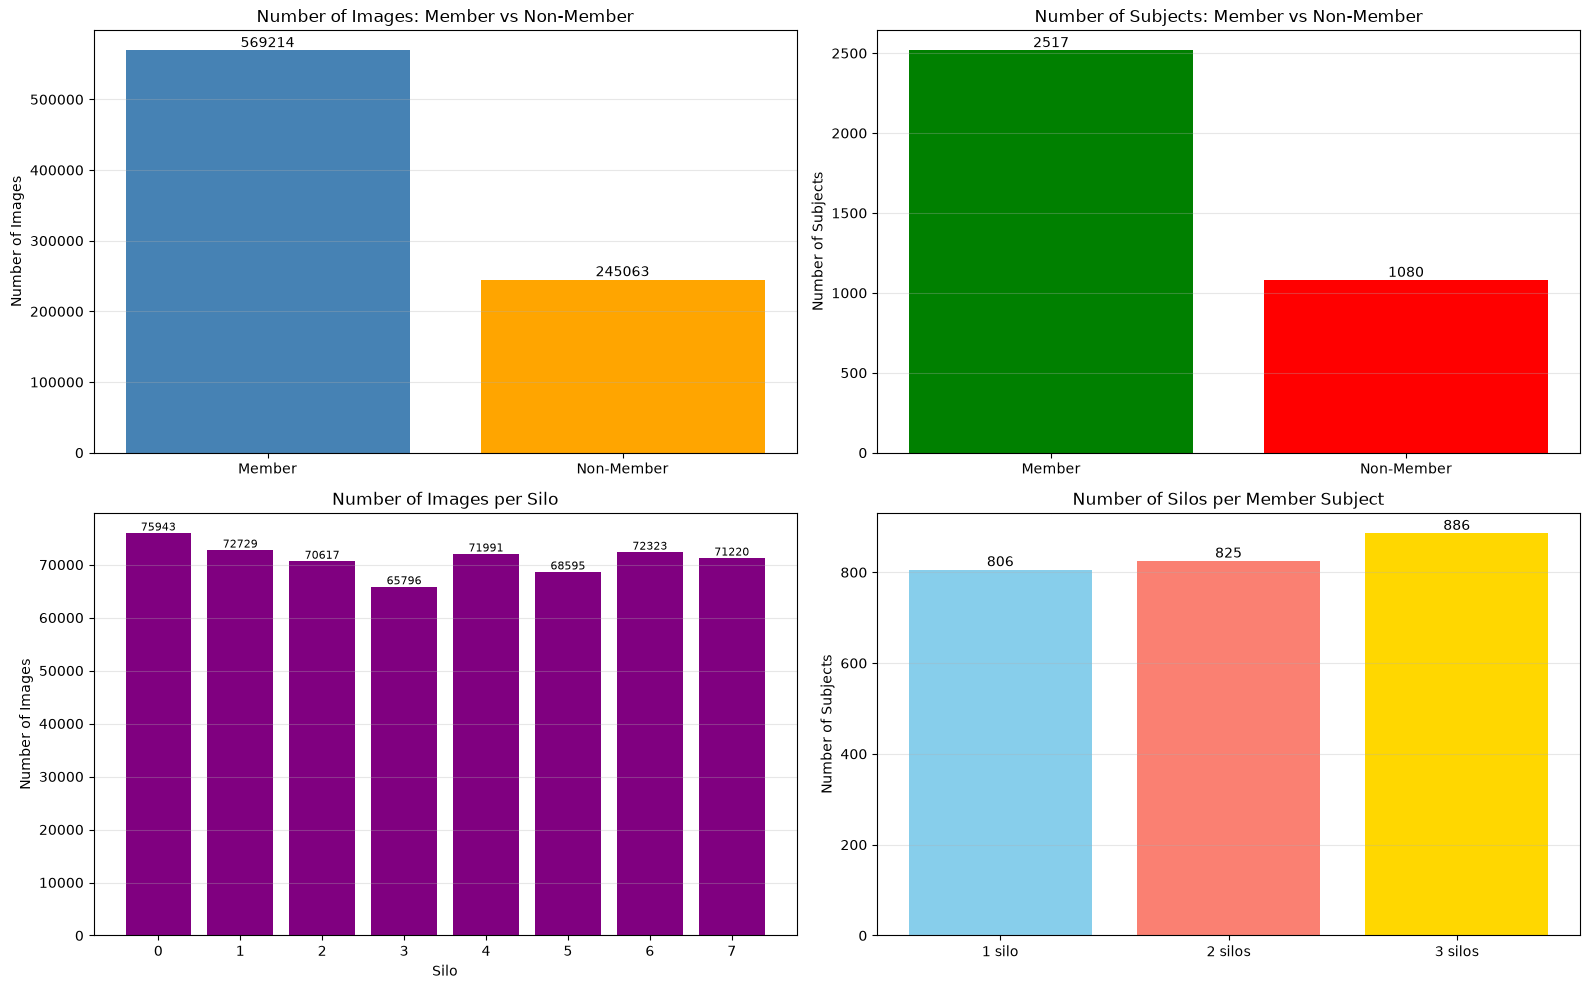

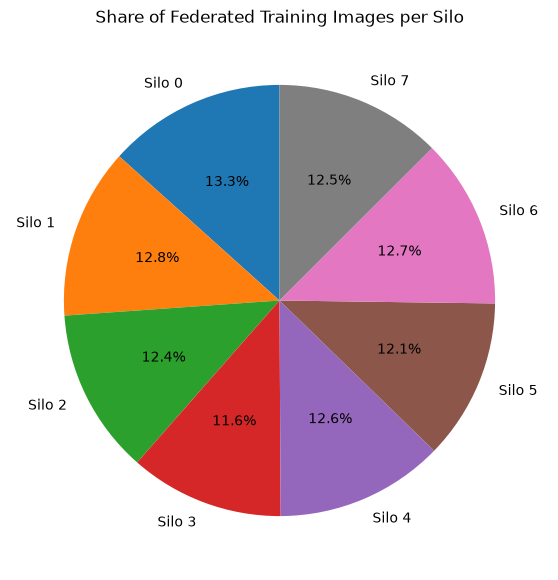

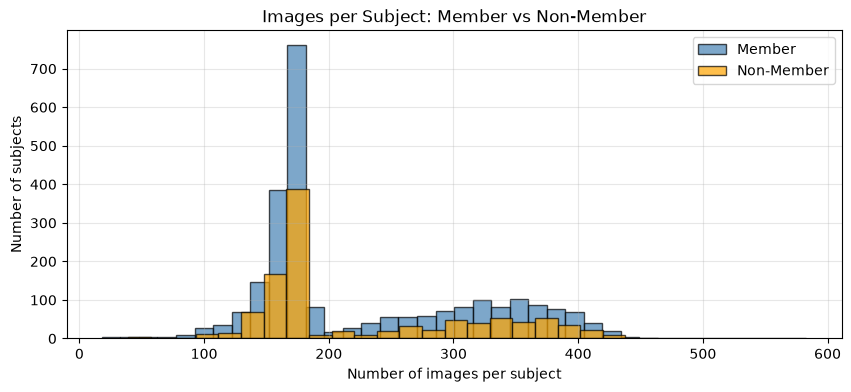

Silo balance ratio max/min: 1.15
Coefficient of variation across silo sizes: 0.039


In [8]:
set_seed(SEED)
member_writer_counts = Counter()
non_member_writer_counts = Counter()

for idx in member_indices:
    writer = full_data[idx]["writer_id"]
    member_writer_counts[writer] += 1

for idx in non_member_indices:
    writer = full_data[idx]["writer_id"]
    non_member_writer_counts[writer] += 1

member_nonmember_df = pd.DataFrame({
    "group": ["Member", "Non-Member"],
    "num_subjects": [len(member_subjects), len(non_member_subjects)],
    "num_images": [len(member_indices), len(non_member_indices)],
    "image_percent": [
        100 * len(member_indices) / len(full_data),
        100 * len(non_member_indices) / len(full_data)
    ]
})

print("MEMBER / NON-MEMBER SUMMARY")
display(member_nonmember_df)

print("MEMBER IMAGES PER SUBJECT")
print("Min:", min(member_writer_counts.values()))
print("Max:", max(member_writer_counts.values()))
print("Mean:", round(np.mean(list(member_writer_counts.values())), 2))
print("Median:", round(np.median(list(member_writer_counts.values())), 2))

print("\nNON-MEMBER IMAGES PER SUBJECT")
print("Min:", min(non_member_writer_counts.values()))
print("Max:", max(non_member_writer_counts.values()))
print("Mean:", round(np.mean(list(non_member_writer_counts.values())), 2))
print("Median:", round(np.median(list(non_member_writer_counts.values())), 2))

silo_sizes = [len(silo_data[s]) for s in range(NUM_SILOS)]
total_training_images = sum(silo_sizes)

silo_shares = [
    100 * size / total_training_images
    for size in silo_sizes
]

silo_summary_df = pd.DataFrame({
    "silo": list(range(NUM_SILOS)),
    "num_images": silo_sizes,
    "share_percent": silo_shares
})

display(silo_summary_df)

writer_silo_map = defaultdict(set)

for s in range(NUM_SILOS):
    for idx in silo_data[s]:
        writer = full_data[idx]["writer_id"]
        writer_silo_map[writer].add(s)

silo_counts_per_subject = [
    len(silos)
    for silos in writer_silo_map.values()
]

one_silo_subjects = sum(1 for x in silo_counts_per_subject if x == 1)
two_silo_subjects = sum(1 for x in silo_counts_per_subject if x == 2)
three_silo_subjects = sum(1 for x in silo_counts_per_subject if x == 3)

multi_silo_subjects = two_silo_subjects + three_silo_subjects

one_silo_percent = 100 * one_silo_subjects / len(silo_counts_per_subject)
multi_silo_percent = 100 * multi_silo_subjects / len(silo_counts_per_subject)

print("\nTotal member subjects in silos:", len(silo_counts_per_subject))
print("Average number of silos per subject:", round(np.mean(silo_counts_per_subject), 2))
print("Subjects in exactly 1 silo:", one_silo_subjects)
print("Subjects in exactly 2 silos:", two_silo_subjects)
print("Subjects in exactly 3 silos:", three_silo_subjects)
print("Percent of subjects in one silo:", round(one_silo_percent, 2), "%")
print("Percent of subjects in multiple silos:", round(multi_silo_percent, 2), "%")


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(member_nonmember_df["group"], member_nonmember_df["num_images"], color=["steelblue", "orange"])
axes[0, 0].set_title("Number of Images: Member vs Non-Member")
axes[0, 0].set_ylabel("Number of Images")
axes[0, 0].grid(axis="y", alpha=0.3)

for i, v in enumerate(member_nonmember_df["num_images"]):
    axes[0, 0].text(i, v, str(v), ha="center", va="bottom")


axes[0, 1].bar(member_nonmember_df["group"], member_nonmember_df["num_subjects"], color=["green", "red"])
axes[0, 1].set_title("Number of Subjects: Member vs Non-Member")
axes[0, 1].set_ylabel("Number of Subjects")
axes[0, 1].grid(axis="y", alpha=0.3)

for i, v in enumerate(member_nonmember_df["num_subjects"]):
    axes[0, 1].text(i, v, str(v), ha="center", va="bottom")


axes[1, 0].bar(range(NUM_SILOS), silo_sizes, color="purple")
axes[1, 0].set_title("Number of Images per Silo")
axes[1, 0].set_xlabel("Silo")
axes[1, 0].set_ylabel("Number of Images")
axes[1, 0].set_xticks(range(NUM_SILOS))
axes[1, 0].grid(axis="y", alpha=0.3)

for i, v in enumerate(silo_sizes):
    axes[1, 0].text(i, v, str(v), ha="center", va="bottom", fontsize=8)


axes[1, 1].bar(["1 silo", "2 silos", "3 silos"], [one_silo_subjects, two_silo_subjects, three_silo_subjects], color=["skyblue", "salmon", "gold"])
axes[1, 1].set_title("Number of Silos per Member Subject")
axes[1, 1].set_ylabel("Number of Subjects")
axes[1, 1].grid(axis="y", alpha=0.3)

for i, v in enumerate([one_silo_subjects, two_silo_subjects, three_silo_subjects]):
    axes[1, 1].text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 7))
plt.pie(silo_shares, labels=[f"Silo {s}" for s in range(NUM_SILOS)], autopct="%1.1f%%", startangle=90)
plt.title("Share of Federated Training Images per Silo")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(list(member_writer_counts.values()), bins=30, alpha=0.7, label="Member", color="steelblue", edgecolor="black")
plt.hist(list(non_member_writer_counts.values()), bins=30, alpha=0.7, label="Non-Member", color="orange", edgecolor="black")
plt.title("Images per Subject: Member vs Non-Member")
plt.xlabel("Number of images per subject")
plt.ylabel("Number of subjects")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


balance_ratio = max(silo_sizes) / max(1, min(silo_sizes))
cv = np.std(silo_sizes) / np.mean(silo_sizes)

print("Silo balance ratio max/min:", round(balance_ratio, 2))
print("Coefficient of variation across silo sizes:", round(cv, 3))

# 2

In [9]:
set_seed(SEED)

label_to_idx = {label: i for i, label in enumerate(unique_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
NUM_CLASSES = len(unique_labels)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class FEMNISTSubset(Dataset):
    def __init__(self, hf_dataset, indices):
        self.ds = hf_dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        sample = self.ds[self.indices[i]]
        image = np.array(sample["image"])
        image = transform(image)
        label = label_to_idx[sample["character"]]
        return image, label

class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

temp_model = SmallCNN(NUM_CLASSES)
print("Number of classes:", NUM_CLASSES)
print("Total model parameters:", sum(p.numel() for p in temp_model.parameters()))


Number of classes: 62
Total model parameters: 428350


In [10]:
set_seed(SEED)

torch.backends.cudnn.benchmark = True

BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
TEST_RATIO = 0.20

PIN_MEMORY = torch.cuda.is_available()
NUM_WORKERS = 0

rng_test = np.random.default_rng(SEED + 2)

all_images = []
all_labels = []
all_writer_ids = []

for item in full_data:
    img = item["image"]
    lbl = item["character"]
    wid = item["writer_id"]

    if isinstance(img, np.ndarray):
        x = torch.tensor(img, dtype=torch.float32)
    else:
        x = torch.tensor(np.array(img), dtype=torch.float32)

    if x.ndim == 2:
        x = x.unsqueeze(0)
    elif x.ndim == 3 and x.shape[0] != 1:
        if x.shape[-1] == 1:
            x = x.permute(2, 0, 1)
    
    if x.max() > 1:
        x = x / 255.0

    all_images.append(x)
    all_labels.append(label_to_idx[lbl])
    all_writer_ids.append(wid)

X_all = torch.stack(all_images)
y_all = torch.tensor(all_labels, dtype=torch.long)
writer_all = np.array(all_writer_ids)

print("Cached tensor shapes:")
print("X_all:", X_all.shape)
print("y_all:", y_all.shape)

class CachedTensorSubset(Dataset):
    def __init__(self, X, y, indices):
        self.X = X
        self.y = y
        self.indices = torch.tensor(indices, dtype=torch.long)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        return self.X[real_idx], self.y[real_idx]

silo_train_indices = {}
silo_test_indices = {}
global_test_indices = []

for s in range(NUM_SILOS):
    indices = np.array(silo_data[s]).copy()
    rng_test.shuffle(indices)

    split_point = int((1 - TEST_RATIO) * len(indices))

    if split_point <= 0:
        split_point = 1
    if split_point >= len(indices):
        split_point = len(indices) - 1

    train_part = indices[:split_point].tolist()
    test_part = indices[split_point:].tolist()

    silo_train_indices[s] = train_part
    silo_test_indices[s] = test_part
    global_test_indices.extend(test_part)

silo_loaders = {}
for s in range(NUM_SILOS):
    train_ds = CachedTensorSubset(X_all, y_all, silo_train_indices[s])
    silo_loaders[s] = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))

all_silo_train_indices = []
for s in range(NUM_SILOS):
    all_silo_train_indices.extend(silo_train_indices[s])

global_train_ds = CachedTensorSubset(X_all, y_all, all_silo_train_indices)
global_test_ds = CachedTensorSubset(X_all, y_all, global_test_indices)

global_train_loader = DataLoader(global_train_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))

test_loader = DataLoader(global_test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))

print("TRAIN / TEST SPLIT SUMMARY")
for s in range(NUM_SILOS):
    print(f"Silo {s}: train={len(silo_train_indices[s])}, test={len(silo_test_indices[s])}")

print("Global train set size:", len(all_silo_train_indices))
print("Global test set size :", len(global_test_indices))

Cached tensor shapes:
X_all: torch.Size([814277, 1, 28, 28])
y_all: torch.Size([814277])
TRAIN / TEST SPLIT SUMMARY
Silo 0: train=60754, test=15189
Silo 1: train=58183, test=14546
Silo 2: train=56493, test=14124
Silo 3: train=52636, test=13160
Silo 4: train=57592, test=14399
Silo 5: train=54876, test=13719
Silo 6: train=57858, test=14465
Silo 7: train=56976, test=14244
Global train set size: 455368
Global test set size : 113846


In [11]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def local_train(global_model, loader, local_epochs=1, lr=0.01):
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()

    optimizer = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=0.9)

    for _ in range(local_epochs):
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = local_model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return copy.deepcopy(local_model.state_dict())


def fed_avg(local_states, local_weights):
    total_weight = sum(local_weights)
    new_state = copy.deepcopy(local_states[0])

    for key in new_state.keys():
        new_state[key] = sum(local_states[i][key] * (local_weights[i] / total_weight) for i in range(len(local_states)))

    return new_state

In [12]:
set_seed(SEED)

NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
LR = 0.01

global_model = SmallCNN(NUM_CLASSES).to(DEVICE)

round_train_losses = []
round_train_accs = []
round_test_losses = []
round_test_accs = []
global_snapshots = []

progress_bar = tqdm(range(1, NUM_ROUNDS + 1), desc="Federated Training",leave=True)

for rnd in progress_bar:
    start_time = time.time()

    local_states = []
    local_weights = []

    for s in range(NUM_SILOS):
        local_state = local_train(
            global_model=global_model,
            loader=silo_loaders[s],
            local_epochs=LOCAL_EPOCHS,
            lr=LR
        )

        local_states.append(local_state)
        local_weights.append(len(silo_loaders[s].dataset))

    new_global_state = fed_avg(local_states, local_weights)
    global_model.load_state_dict(new_global_state)

    train_loss, train_acc = evaluate(global_model, global_train_loader)
    test_loss, test_acc = evaluate(global_model, test_loader)

    elapsed_time = time.time() - start_time

    round_train_losses.append(train_loss)
    round_train_accs.append(train_acc)
    round_test_losses.append(test_loss)
    round_test_accs.append(test_acc)

    global_snapshots.append(copy.deepcopy(global_model.state_dict()))

    progress_bar.set_postfix({"round": f"{rnd}/{NUM_ROUNDS}", "tr_loss": f"{train_loss:.4f}", "tr_acc": f"{train_acc:.4f}", "te_loss": f"{test_loss:.4f}", "te_acc": f"{test_acc:.4f}"})

print("\nTRAINING COMPLETE")
print("Final train loss:", round(round_train_losses[-1], 4))
print("Final train acc :", round(round_train_accs[-1], 4))
print("Final test loss :", round(round_test_losses[-1], 4))
print("Final test acc  :", round(round_test_accs[-1], 4))
print("Best test acc   :", round(max(round_test_accs), 4))


Federated Training:   0%|          | 0/10 [00:00<?, ?it/s]


TRAINING COMPLETE
Final train loss: 0.5966
Final train acc : 0.8113
Final test loss : 0.6016
Final test acc  : 0.8089
Best test acc   : 0.8089


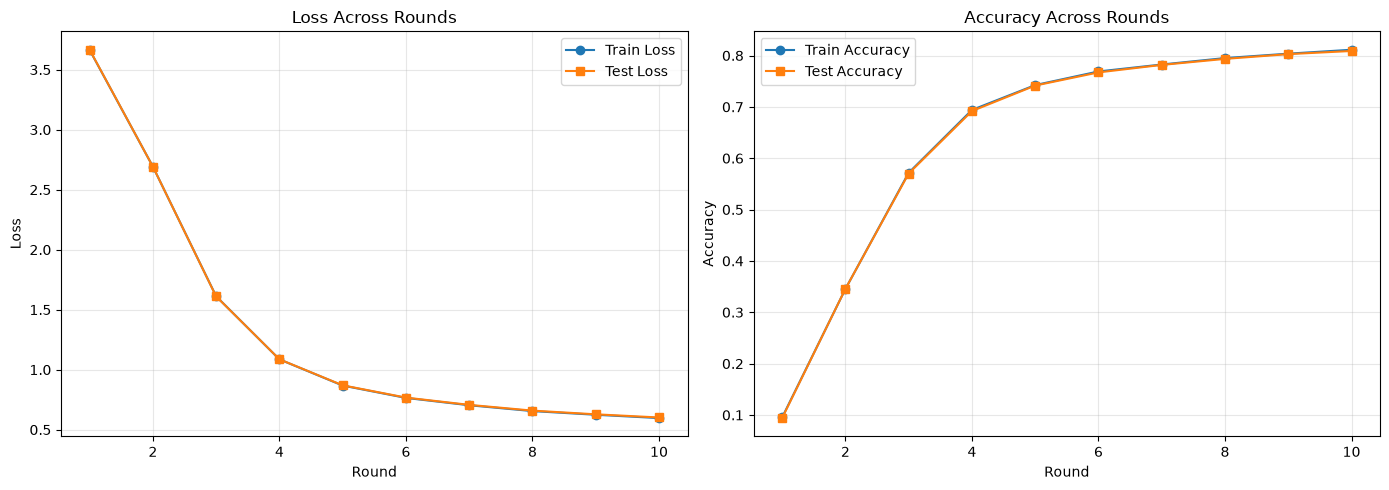

FINAL GLOBAL MODEL PERFORMANCE
Final train accuracy: 0.8113
Final test accuracy : 0.8089
Best test accuracy  : 0.8089
Final train loss    : 0.5966
Final test loss     : 0.6016


In [13]:
round_axis = range(1, NUM_ROUNDS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(round_axis, round_train_losses, marker="o", label="Train Loss")
plt.plot(round_axis, round_test_losses, marker="s", label="Test Loss")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.title("Loss Across Rounds")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(round_axis, round_train_accs, marker="o", label="Train Accuracy")
plt.plot(round_axis, round_test_accs, marker="s", label="Test Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.title("Accuracy Across Rounds")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("FINAL GLOBAL MODEL PERFORMANCE")
print("Final train accuracy:", round(round_train_accs[-1], 4))
print("Final test accuracy :", round(round_test_accs[-1], 4))
print("Best test accuracy  :", round(max(round_test_accs), 4))
print("Final train loss    :", round(round_train_losses[-1], 4))
print("Final test loss     :", round(round_test_losses[-1], 4))

# 3

In [21]:
set_seed(SEED)

ATTACK_BATCH_SIZE = 512
MAX_RECORD_ATTACK_SAMPLES = 1000000000

MAX_ATTACK_SUBJECTS_PER_CLASS = 1000000000
MAX_RECORDS_PER_SUBJECT = 1000000000

rng_attack = np.random.default_rng(SEED + 10)

def build_model_from_state(state_dict):
    model = SmallCNN(NUM_CLASSES).to(DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def make_cached_loader_from_indices(indices, batch_size=ATTACK_BATCH_SIZE, shuffle=False):
    ds = CachedTensorSubset(X_all, y_all, indices)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))
    return loader

def evaluate_losses_on_loader(model, loader):
    model.eval()
    losses_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            logits = model(x)
            losses = F.cross_entropy(logits, y, reduction="none")
            losses_all.append(losses.detach().cpu())

    return torch.cat(losses_all).numpy()

def validate_indices(indices, name):
    indices = list(indices)
    bad = [idx for idx in indices if idx < 0 or idx >= len(X_all)]
    if len(bad) > 0:
        raise ValueError(f"{name} contains invalid indices. Example bad indices: {bad[:5]}")

def compute_attack_metrics(y_true, scores):
    threshold = np.median(scores)
    preds = (scores >= threshold).astype(int)

    return {"threshold": threshold, "preds": preds, "accuracy": accuracy_score(y_true, preds), "precision": precision_score(y_true, preds, zero_division=0), "recall": recall_score(y_true, preds, zero_division=0), "f1": f1_score(y_true, preds, zero_division=0), "auc": roc_auc_score(y_true, scores)}

subject_to_indices = defaultdict(list)

for idx, wid in enumerate(writer_all):
    subject_to_indices[wid].append(idx)

available_member_subjects = [sid for sid in member_subjects if sid in subject_to_indices]
available_non_member_subjects = [sid for sid in non_member_subjects if sid in subject_to_indices]

n_subjects_attack = min(len(available_member_subjects), len(available_non_member_subjects), MAX_ATTACK_SUBJECTS_PER_CLASS)

if n_subjects_attack == 0:
    raise ValueError("No valid member/non-member subjects available for subject-level MIA.")

member_subject_list = rng_attack.choice(available_member_subjects, n_subjects_attack, replace=False).tolist()

non_member_subject_list = rng_attack.choice(available_non_member_subjects, n_subjects_attack, replace=False).tolist()

attack_subjects = member_subject_list + non_member_subject_list
subject_true_labels = np.array([1] * len(member_subject_list) + [0] * len(non_member_subject_list))

subject_attack_indices = []
subject_positions = {}

cursor = 0

for sid in attack_subjects:
    idxs = list(subject_to_indices[sid])

    if len(idxs) > MAX_RECORDS_PER_SUBJECT:
        idxs = rng_attack.choice(idxs, MAX_RECORDS_PER_SUBJECT, replace=False).tolist()

    validate_indices(idxs, f"indices of subject {sid}")

    subject_attack_indices.extend(idxs)
    subject_positions[sid] = np.arange(cursor, cursor + len(idxs))
    cursor += len(idxs)

subject_attack_loader = make_cached_loader_from_indices(subject_attack_indices, batch_size=ATTACK_BATCH_SIZE, shuffle=False)

member_record_pool = list(all_silo_train_indices)
non_member_record_pool = list(non_member_indices)

validate_indices(member_record_pool, "all_silo_train_indices")
validate_indices(non_member_record_pool, "non_member_indices")

n_record_attack = min(len(member_record_pool), len(non_member_record_pool), MAX_RECORD_ATTACK_SAMPLES)

if n_record_attack == 0:
    raise ValueError("No valid member/non-member records available for record-level MIA.")

member_record_sample = rng_attack.choice(member_record_pool, n_record_attack, replace=False).tolist()

non_member_record_sample = rng_attack.choice(non_member_record_pool, n_record_attack, replace=False).tolist()

record_attack_indices = member_record_sample + non_member_record_sample
record_true_labels = np.array([1] * len(member_record_sample) + [0] * len(non_member_record_sample))

record_attack_loader = make_cached_loader_from_indices(record_attack_indices, batch_size=ATTACK_BATCH_SIZE, shuffle=False)

print("ATTACK PREPARATION COMPLETED")
print("Subject-level attack subjects:", len(attack_subjects))
print("  Member subjects           :", len(member_subject_list))
print("  Non-member subjects       :", len(non_member_subject_list))
print("Subject-level attack records :", len(subject_attack_indices))
print("Record-level attack records  :", len(record_attack_indices))
print("  Member records             :", len(member_record_sample))
print("  Non-member records         :", len(non_member_record_sample))
print("Attack rounds available      :", len(global_snapshots))


ATTACK PREPARATION COMPLETED
Subject-level attack subjects: 2160
  Member subjects           : 1080
  Non-member subjects       : 1080
Subject-level attack records : 489007
Record-level attack records  : 490126
  Member records             : 245063
  Non-member records         : 245063
Attack rounds available      : 10


In [ ]:
set_seed(SEED)

num_rounds_attack = len(global_snapshots)

subject_record_loss_matrix = np.zeros((len(subject_attack_indices), num_rounds_attack), dtype=np.float32)

subject_loss_matrix = np.zeros((len(attack_subjects), num_rounds_attack), dtype=np.float32)

record_loss_matrix = np.zeros((len(record_attack_indices), num_rounds_attack), dtype=np.float32)

for r, state in enumerate(tqdm(global_snapshots, desc="MIA loss computation")):
    temp_model = build_model_from_state(state)

    subject_record_losses_r = evaluate_losses_on_loader(temp_model, subject_attack_loader)

    subject_record_loss_matrix[:, r] = subject_record_losses_r

    for i, sid in enumerate(attack_subjects):
        pos = subject_positions[sid]
        subject_loss_matrix[i, r] = float(subject_record_losses_r[pos].mean())

    record_loss_matrix[:, r] = evaluate_losses_on_loader(temp_model, record_attack_loader)

    del temp_model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

member_mask_subj = (subject_true_labels == 1)
nonmember_mask_subj = (subject_true_labels == 0)

member_centroid = subject_loss_matrix[member_mask_subj].mean(axis=0)
nonmember_centroid = subject_loss_matrix[nonmember_mask_subj].mean(axis=0)

dist_to_member = np.linalg.norm(subject_loss_matrix - member_centroid[None, :], axis=1)
dist_to_nonmember = np.linalg.norm(subject_loss_matrix - nonmember_centroid[None, :], axis=1)

subject_scores = dist_to_nonmember - dist_to_member
subject_final_metrics = compute_attack_metrics(subject_true_labels, subject_scores)

subject_threshold = subject_final_metrics["threshold"]
subject_preds = subject_final_metrics["preds"]

acc_subj = subject_final_metrics["accuracy"]
prec_subj = subject_final_metrics["precision"]
rec_subj = subject_final_metrics["recall"]
f1_subj = subject_final_metrics["f1"]
auc_subj = subject_final_metrics["auc"]

print("SUBJECT-LEVEL ATTACK: LOSS-ACROSS-ROUNDS (TRAJECTORY-BASED)")
print("Accuracy :", round(acc_subj, 4))
print("Precision:", round(prec_subj, 4))
print("Recall   :", round(rec_subj, 4))
print("F1-score :", round(f1_subj, 4))
print("AUC      :", round(auc_subj, 4))
print("Threshold:", round(subject_threshold, 4))
print("Confusion matrix:\n", confusion_matrix(subject_true_labels, subject_preds))


record_scores = -record_loss_matrix[:, -1]
record_final_metrics = compute_attack_metrics(record_true_labels, record_scores)

record_threshold = record_final_metrics["threshold"]
record_preds = record_final_metrics["preds"]

acc_rec = record_final_metrics["accuracy"]
prec_rec = record_final_metrics["precision"]
rec_rec = record_final_metrics["recall"]
f1_rec = record_final_metrics["f1"]
auc_rec = record_final_metrics["auc"]

print("\nRECORD-LEVEL ATTACK: FINAL-ROUND LOSS BASELINE")
print("Accuracy :", round(acc_rec, 4))
print("Precision:", round(prec_rec, 4))
print("Recall   :", round(rec_rec, 4))
print("F1-score :", round(f1_rec, 4))
print("AUC      :", round(auc_rec, 4))
print("Threshold:", round(record_threshold, 4))
print("Confusion matrix:\n", confusion_matrix(record_true_labels, record_preds))


MIA loss computation:   0%|          | 0/10 [00:00<?, ?it/s]

SUBJECT-LEVEL ATTACK: LOSS-ACROSS-ROUNDS (TRAJECTORY-BASED)
Accuracy : 0.4981
Precision: 0.4981
Recall   : 0.4981
F1-score : 0.4981
AUC      : 0.5107
Threshold: -0.0151
Confusion matrix:
 [[538 542]
 [542 538]]

RECORD-LEVEL ATTACK: FINAL-ROUND LOSS BASELINE
Accuracy : 0.5008
Precision: 0.5008
Recall   : 0.5008
F1-score : 0.5008
AUC      : 0.5007
Threshold: -0.1664
Confusion matrix:
 [[122717 122346]
 [122345 122718]]


In [ ]:
subject_acc_per_round = []
subject_prec_per_round = []
subject_rec_per_round = []
subject_f1_per_round = []
subject_auc_per_round = []

record_acc_per_round = []
record_prec_per_round = []
record_rec_per_round = []
record_f1_per_round = []
record_auc_per_round = []

for r in range(1, num_rounds_attack + 1):
    subject_features_r = subject_loss_matrix[:, :r]

    member_centroid_r = subject_features_r[subject_true_labels == 1].mean(axis=0)
    nonmember_centroid_r = subject_features_r[subject_true_labels == 0].mean(axis=0)

    dist_to_member_r = np.linalg.norm(subject_features_r - member_centroid_r[None, :], axis=1)
    dist_to_nonmember_r = np.linalg.norm(subject_features_r - nonmember_centroid_r[None, :], axis=1)

    subject_scores_r = dist_to_nonmember_r - dist_to_member_r
    subject_metrics_r = compute_attack_metrics(subject_true_labels, subject_scores_r)

    subject_acc_per_round.append(subject_metrics_r["accuracy"])
    subject_prec_per_round.append(subject_metrics_r["precision"])
    subject_rec_per_round.append(subject_metrics_r["recall"])
    subject_f1_per_round.append(subject_metrics_r["f1"])
    subject_auc_per_round.append(subject_metrics_r["auc"])

    record_scores_r = -record_loss_matrix[:, r - 1]
    record_metrics_r = compute_attack_metrics(record_true_labels, record_scores_r)

    record_acc_per_round.append(record_metrics_r["accuracy"])
    record_prec_per_round.append(record_metrics_r["precision"])
    record_rec_per_round.append(record_metrics_r["recall"])
    record_f1_per_round.append(record_metrics_r["f1"])
    record_auc_per_round.append(record_metrics_r["auc"])

attack_metrics_per_round = pd.DataFrame({
    "Round": np.arange(1, num_rounds_attack + 1),

    "Subject_Accuracy": subject_acc_per_round,
    "Subject_Precision": subject_prec_per_round,
    "Subject_Recall": subject_rec_per_round,
    "Subject_F1": subject_f1_per_round,
    "Subject_AUC": subject_auc_per_round,

    "Record_Accuracy": record_acc_per_round,
    "Record_Precision": record_prec_per_round,
    "Record_Recall": record_rec_per_round,
    "Record_F1": record_f1_per_round,
    "Record_AUC": record_auc_per_round
})

print("ATTACK METRICS ACROSS ROUNDS")
display(attack_metrics_per_round)


ATTACK METRICS ACROSS ROUNDS


,Round,Subject_Accuracy,Subject_Precision,Subject_Recall,Subject_F1,Subject_AUC,Record_Accuracy,Record_Precision,Record_Recall,Record_F1,Record_AUC
0,1,0.494907,0.495638,0.578704,0.533960,0.495478,0.500651,0.500651,0.500651,0.500651,0.501875
1,2,0.510185,0.510185,0.510185,0.510185,0.509699,0.501712,0.501712,0.501712,0.501712,0.502031
2,3,0.511111,0.511111,0.511111,0.511111,0.518894,0.501014,0.501014,0.501014,0.501014,0.500734
3,4,0.510185,0.510185,0.510185,0.510185,0.516632,0.501039,0.501039,0.501039,0.501039,0.500719
4,5,0.511111,0.511111,0.511111,0.511111,0.514781,0.500614,0.500614,0.500614,0.500614,0.500652
5,6,0.506481,0.506481,0.506481,0.506481,0.513302,0.500996,0.500996,0.500998,0.500997,0.500696
6,7,0.502778,0.502778,0.502778,0.502778,0.512280,0.500900,0.500900,0.500900,0.500900,0.500627
7,8,0.501852,0.501852,0.501852,0.501852,0.511585,0.500598,0.500598,0.500598,0.500598,0.500645
8,9,0.500926,0.500926,0.500926,0.500926,0.510871,0.500533,0.500533,0.500533,0.500533,0.500563
9,10,0.498148,0.498148,0.498148,0.498148,0.510731,0.500759,0.500759,0.500761,0.500760,0.500687


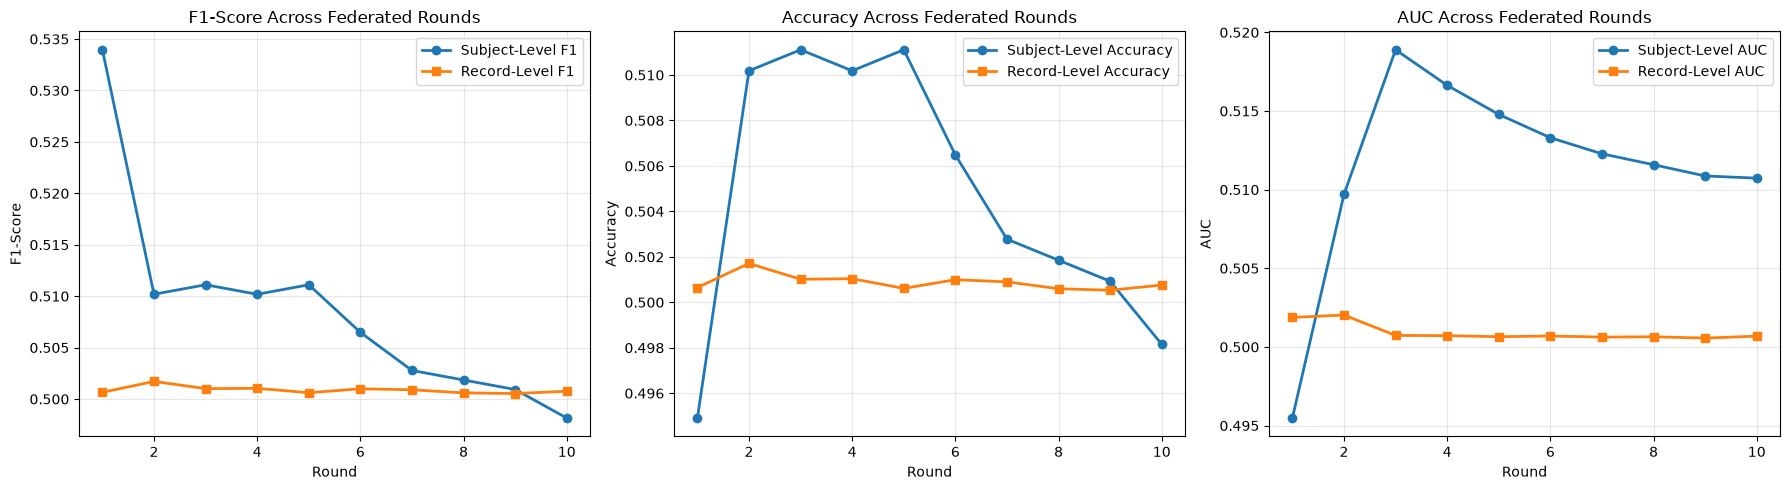

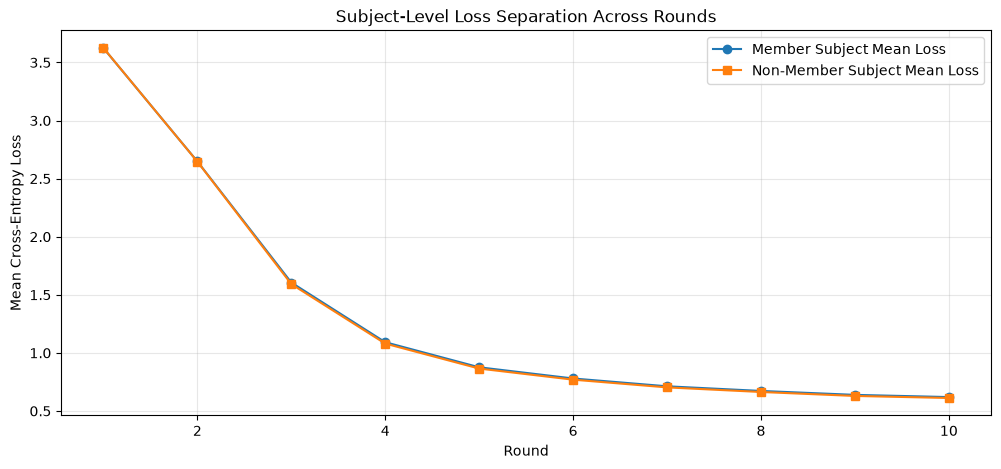

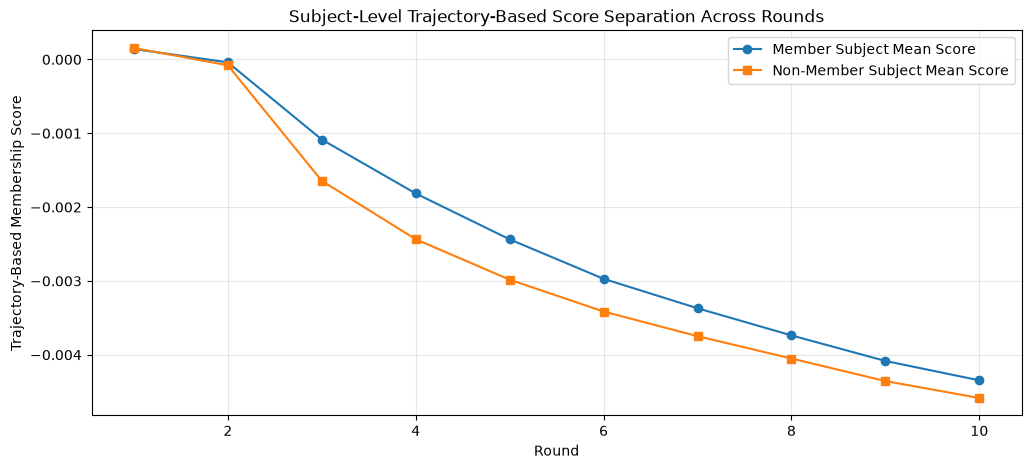

In [ ]:
round_axis = np.arange(1, num_rounds_attack + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(round_axis, subject_f1_per_round, marker="o", linewidth=2, label="Subject-Level F1")

axes[0].plot(round_axis, record_f1_per_round, marker="s", linewidth=2, label="Record-Level F1")

axes[0].set_title("F1-Score Across Federated Rounds")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("F1-Score")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(round_axis, subject_acc_per_round, marker="o", linewidth=2, label="Subject-Level Accuracy")

axes[1].plot(round_axis, record_acc_per_round, marker="s", linewidth=2, label="Record-Level Accuracy")

axes[1].set_title("Accuracy Across Federated Rounds")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(round_axis, subject_auc_per_round, marker="o", linewidth=2, label="Subject-Level AUC")

axes[2].plot(round_axis, record_auc_per_round, marker="s", linewidth=2, label="Record-Level AUC")

axes[2].set_title("AUC Across Federated Rounds")
axes[2].set_xlabel("Round")
axes[2].set_ylabel("AUC")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

member_subject_losses = subject_loss_matrix[subject_true_labels == 1].mean(axis=0)
nonmember_subject_losses = subject_loss_matrix[subject_true_labels == 0].mean(axis=0)

plt.plot(round_axis, member_subject_losses, marker="o", label="Member Subject Mean Loss")
plt.plot(round_axis, nonmember_subject_losses, marker="s", label="Non-Member Subject Mean Loss")
plt.xlabel("Round")
plt.ylabel("Mean Cross-Entropy Loss")
plt.title("Subject-Level Loss Separation Across Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))

member_scores_progress = []
nonmember_scores_progress = []

for r in range(1, num_rounds_attack + 1):
    feats_r = subject_loss_matrix[:, :r]

    member_centroid_r = feats_r[subject_true_labels == 1].mean(axis=0)
    nonmember_centroid_r = feats_r[subject_true_labels == 0].mean(axis=0)

    d_mem_r = np.linalg.norm(feats_r - member_centroid_r[None, :], axis=1)
    d_non_r = np.linalg.norm(feats_r - nonmember_centroid_r[None, :], axis=1)

    scores_r = d_non_r - d_mem_r

    member_scores_progress.append(scores_r[subject_true_labels == 1].mean())
    nonmember_scores_progress.append(scores_r[subject_true_labels == 0].mean())

plt.plot(round_axis, member_scores_progress, marker="o", label="Member Subject Mean Score")
plt.plot(round_axis, nonmember_scores_progress, marker="s", label="Non-Member Subject Mean Score")
plt.xlabel("Round")
plt.ylabel("Trajectory-Based Membership Score")
plt.title("Subject-Level Trajectory-Based Score Separation Across Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# 4

In [27]:
set_seed(SEED)

TARGET_EPSILON = 4.0
TARGET_DELTA = 1e-5

RECORD_DP_NOISE_MULT = 1.0
RECORD_DP_CLIP_NORM = 1.0

SUBJECT_DP_NOISE_MULT = 1.0
SUBJECT_DP_CLIP_NORM = 1.0

DP_NUM_ROUNDS = 8
DP_LOCAL_EPOCHS = LOCAL_EPOCHS
DP_LR = 0.1
DP_BATCH_SIZE = BATCH_SIZE

dp_silo_indices = []

for s in range(NUM_SILOS):
    idxs = list(silo_train_indices[s])
    validate_indices(idxs, f"silo_train_indices[{s}]")
    dp_silo_indices.append(idxs)

print(f"Target privacy budget: epsilon≈{TARGET_EPSILON}, delta={TARGET_DELTA}")
print(f"DP rounds       : {DP_NUM_ROUNDS}")
print(f"Local epochs    : {DP_LOCAL_EPOCHS}")
print(f"Learning rate   : {DP_LR}")
print(f"Batch size      : {DP_BATCH_SIZE}")
print(f"Record-DP sigma : {RECORD_DP_NOISE_MULT}")
print(f"Record-DP clip  : {RECORD_DP_CLIP_NORM}")
print(f"Subject-DP sigma: {SUBJECT_DP_NOISE_MULT}")
print(f"Subject-DP clip : {SUBJECT_DP_CLIP_NORM}")
print("Number of silos :", len(dp_silo_indices))
print("Silo train sizes:", [len(x) for x in dp_silo_indices])


Target privacy budget: epsilon≈4.0, delta=1e-05
DP rounds       : 8
Local epochs    : 1
Learning rate   : 0.1
Batch size      : 256
Record-DP sigma : 1.0
Record-DP clip  : 1.0
Subject-DP sigma: 1.0
Subject-DP clip : 1.0
Number of silos : 8
Silo train sizes: [60754, 58183, 56493, 52636, 57592, 54876, 57858, 56976]


In [28]:
def make_dp_loader(indices, batch_size=DP_BATCH_SIZE, shuffle=True):
    validate_indices(indices, "DP loader indices")
    ds = CachedTensorSubset(X_all, y_all, indices)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))
    return loader


def compose_epsilon_conservative(previous_eps, round_eps):
    if not np.isfinite(previous_eps) or not np.isfinite(round_eps):
        return np.inf

    return float(previous_eps + round_eps)


def compute_losses_for_snapshots(snapshot_list):
    num_rounds_local = len(snapshot_list)

    subject_record_loss_mat = np.zeros((len(subject_attack_indices), num_rounds_local), dtype=np.float32)

    subject_loss_mat = np.zeros((len(attack_subjects), num_rounds_local), dtype=np.float32)

    record_loss_mat = np.zeros((len(record_attack_indices), num_rounds_local), dtype=np.float32)

    for r, state in enumerate(tqdm(snapshot_list, desc="DP-MIA loss computation")):
        temp_model = build_model_from_state(state)

        subject_record_losses_r = evaluate_losses_on_loader(temp_model, subject_attack_loader)

        subject_record_loss_mat[:, r] = subject_record_losses_r

        for i, sid in enumerate(attack_subjects):
            pos = subject_positions[sid]
            subject_loss_mat[i, r] = float(subject_record_losses_r[pos].mean())

        record_loss_mat[:, r] = evaluate_losses_on_loader(temp_model, record_attack_loader)

        del temp_model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return subject_record_loss_mat, subject_loss_mat, record_loss_mat


def evaluate_mia_from_snapshots(snapshot_list):
    _, subject_loss_mat, record_loss_mat = compute_losses_for_snapshots(snapshot_list)

    subject_scores_dp = -subject_loss_mat.mean(axis=1)
    subject_metrics_dp = compute_attack_metrics(subject_true_labels, subject_scores_dp)

    record_scores_dp = -record_loss_mat[:, -1]
    record_metrics_dp = compute_attack_metrics(record_true_labels, record_scores_dp)

    rows = []

    for r in range(1, len(snapshot_list) + 1):
        subject_scores_r = -subject_loss_mat[:, :r].mean(axis=1)
        subject_metrics_r = compute_attack_metrics(subject_true_labels, subject_scores_r)

        record_scores_r = -record_loss_mat[:, r - 1]
        record_metrics_r = compute_attack_metrics(record_true_labels, record_scores_r)

        rows.append({
            "Round": r,
            "Subject_Accuracy": subject_metrics_r["accuracy"],
            "Subject_Precision": subject_metrics_r["precision"],
            "Subject_Recall": subject_metrics_r["recall"],
            "Subject_F1": subject_metrics_r["f1"],
            "Subject_AUC": subject_metrics_r["auc"],
            "Record_Accuracy": record_metrics_r["accuracy"],
            "Record_Precision": record_metrics_r["precision"],
            "Record_Recall": record_metrics_r["recall"],
            "Record_F1": record_metrics_r["f1"],
            "Record_AUC": record_metrics_r["auc"],
        })

    roundwise_df = pd.DataFrame(rows)

    return {
        "subject_loss_matrix": subject_loss_mat,
        "record_loss_matrix": record_loss_mat,
        "subject_scores": subject_scores_dp,
        "record_scores": record_scores_dp,
        "subject_metrics": subject_metrics_dp,
        "record_metrics": record_metrics_dp,
        "roundwise_metrics": roundwise_df
    }


def make_defense_summary(defense_name, result_obj, attack_obj, epsilon_note):
    row = {
        "Defense": defense_name,
        "Final_Test_Accuracy": result_obj["test_accs"][-1],
        "Final_Train_Accuracy": result_obj["train_accs"][-1],
        "Epsilon": result_obj["epsilons"][-1],
        "Delta": TARGET_DELTA,
        "Noise_Multiplier": result_obj["noise_multiplier"],
        "Clip_Norm": result_obj["clip_norm"],

        "Subject_F1": attack_obj["subject_metrics"]["f1"],
        "Subject_AUC": attack_obj["subject_metrics"]["auc"],

        "Record_F1": attack_obj["record_metrics"]["f1"],
        "Record_AUC": attack_obj["record_metrics"]["auc"],

        "Epsilon_Note": epsilon_note
    }

    return pd.DataFrame([row])


def make_no_defense_summary():
    return pd.DataFrame([{
        "Defense": "No Defense",
        "Final_Test_Accuracy": round_test_accs[-1],
        "Final_Train_Accuracy": round_train_accs[-1],
        "Epsilon": np.nan,
        "Delta": np.nan,
        "Noise_Multiplier": 0.0,
        "Clip_Norm": np.nan,

        "Subject_F1": f1_subj,
        "Subject_AUC": auc_subj,

        "Record_F1": f1_rec,
        "Record_AUC": auc_rec,

        "Epsilon_Note": "No DP mechanism"
    }])


In [29]:
def local_train_record_dp(global_model, train_indices, local_epochs=1, lr=0.01, noise_multiplier=1.1, max_grad_norm=1.0, batch_size=256):

    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()

    train_loader = make_dp_loader(train_indices, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=0.9)

    privacy_engine = PrivacyEngine()

    local_model, optimizer, private_loader = privacy_engine.make_private(module=local_model, optimizer=optimizer, data_loader=train_loader, noise_multiplier=noise_multiplier, max_grad_norm=max_grad_norm)

    for _ in range(local_epochs):
        for x, y in private_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            logits = local_model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    per_call_eps = float(privacy_engine.accountant.get_epsilon(delta=TARGET_DELTA))

    clean_state = {k: v.detach().cpu().clone() for k, v in local_model._module.state_dict().items()}

    del local_model, optimizer, private_loader, privacy_engine

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return clean_state, per_call_eps


In [30]:
def train_fedavg_record_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, noise_multiplier=RECORD_DP_NOISE_MULT, max_grad_norm=RECORD_DP_CLIP_NORM, batch_size=DP_BATCH_SIZE):

    model = SmallCNN(NUM_CLASSES).to(DEVICE)

    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []

    round_epsilons = []
    epsilons = []

    snapshots = []

    cumulative_eps = 0.0

    progress_bar = tqdm(range(1, num_rounds + 1), desc="Record-Level DP Federated Training", leave=True)

    for rnd in progress_bar:
        local_states = []
        local_weights = []
        local_eps_this_round = []

        for s in range(NUM_SILOS):
            local_state, local_eps = local_train_record_dp(global_model=model, train_indices=dp_silo_indices[s], local_epochs=local_epochs, lr=lr, noise_multiplier=noise_multiplier, max_grad_norm=max_grad_norm, batch_size=batch_size)

            local_states.append(local_state)
            local_weights.append(len(dp_silo_indices[s]))
            local_eps_this_round.append(local_eps)

        new_global_state = fed_avg(local_states, local_weights)
        model.load_state_dict(new_global_state)

        train_loss, train_acc = evaluate(model, global_train_loader)
        test_loss, test_acc = evaluate(model, test_loader)

        round_eps = float(np.max(local_eps_this_round))
        cumulative_eps = compose_epsilon_conservative(cumulative_eps, round_eps)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        round_epsilons.append(round_eps)
        epsilons.append(cumulative_eps)

        snapshots.append(copy.deepcopy(model.state_dict()))

        progress_bar.set_postfix({"round": f"{rnd}/{num_rounds}", "test_acc": f"{test_acc:.4f}", "round_eps": f"{round_eps:.3f}", "cum_eps": f"{cumulative_eps:.3f}"})

    result = {
        "model": model,
        "train_losses": train_losses,
        "train_accs": train_accs,
        "test_losses": test_losses,
        "test_accs": test_accs,
        "round_epsilons": round_epsilons,
        "epsilons": epsilons,
        "snapshots": snapshots,
        "noise_multiplier": noise_multiplier,
        "clip_norm": max_grad_norm
    }

    return result


record_dp_result = train_fedavg_record_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, noise_multiplier=RECORD_DP_NOISE_MULT, max_grad_norm=RECORD_DP_CLIP_NORM, batch_size=DP_BATCH_SIZE)

record_dp_attack_eval = evaluate_mia_from_snapshots(record_dp_result["snapshots"])

record_dp_summary = make_defense_summary(defense_name="Record-Level DP", result_obj=record_dp_result, attack_obj=record_dp_attack_eval, epsilon_note="Opacus per-local epsilon + conservative composition across FL rounds")

print("RECORD-LEVEL DP SUMMARY")
display(record_dp_summary)

print("\RECORD-LEVEL DP ROUND-WISE MIA")
display(record_dp_attack_eval["roundwise_metrics"])



Record-Level DP Federated Training:   0%|          | 0/8 [00:00<?, ?it/s]

c:\Users\kamya\anaconda3\envs\new_env\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


DP-MIA loss computation:   0%|          | 0/8 [00:00<?, ?it/s]

RECORD-LEVEL DP SUMMARY


,Defense,Final_Test_Accuracy,Final_Train_Accuracy,Epsilon,Delta,Noise_Multiplier,Clip_Norm,Subject_F1,Subject_AUC,Record_F1,Record_AUC,Epsilon_Note
0,Record-Level DP,0.657458,0.659434,3.525268,0.00001,1.0,1.0,0.482407,0.490977,0.501642,0.500891,Opacus per-local epsilon + conservative compos...


\RECORD-LEVEL DP ROUND-WISE MIA


,Round,Subject_Accuracy,Subject_Precision,Subject_Recall,Subject_F1,Subject_AUC,Record_Accuracy,Record_Precision,Record_Recall,Record_F1,Record_AUC
0,1,0.498148,0.498148,0.498148,0.498148,0.498919,0.500647,0.500647,0.500647,0.500647,0.502145
1,2,0.496296,0.496296,0.496296,0.496296,0.499541,0.500365,0.500365,0.500365,0.500365,0.501633
2,3,0.482407,0.482407,0.482407,0.482407,0.493122,0.501036,0.501036,0.501039,0.501037,0.500962
3,4,0.477778,0.477778,0.477778,0.477778,0.490293,0.501463,0.501463,0.501463,0.501463,0.500889
4,5,0.478704,0.478704,0.478704,0.478704,0.489269,0.501226,0.501226,0.501226,0.501226,0.500758
5,6,0.481481,0.481481,0.481481,0.481481,0.489601,0.501781,0.501781,0.501781,0.501781,0.500990
6,7,0.483333,0.483333,0.483333,0.483333,0.490041,0.501430,0.501430,0.501430,0.501430,0.500921
7,8,0.482407,0.482407,0.482407,0.482407,0.490977,0.501642,0.501642,0.501642,0.501642,0.500891


In [ ]:
SUBJECTS_PER_STEP = 8
MAX_RECORDS_PER_SUBJECT_STEP = 128


def approximate_subject_dp_epsilon(num_subjects, noise_multiplier, total_steps, subjects_per_step=1, delta=1e-5):
    if noise_multiplier <= 0:
        return np.inf

    if num_subjects <= 1:
        return np.inf

    q = min(1.0, subjects_per_step / num_subjects)

    eps = q * math.sqrt(2.0 * total_steps * math.log(1.0 / delta)) / noise_multiplier

    return float(eps)


def local_train_subject_dp(global_model, train_indices, local_epochs=1, lr=0.1, clip_norm=1.0, noise_multiplier=1.0, subjects_per_step=SUBJECTS_PER_STEP, max_records_per_subject_step=MAX_RECORDS_PER_SUBJECT_STEP):
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()

    optimizer = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=0.9)

    subject_groups = defaultdict(list)

    for idx in train_indices:
        sid = writer_all[idx]
        subject_groups[sid].append(idx)

    subject_ids = list(subject_groups.keys())
    num_subjects = len(subject_ids)

    if num_subjects == 0:
        clean_state = {k: v.detach().cpu().clone() for k, v in local_model.state_dict().items()}
        return clean_state, np.inf

    total_optimizer_steps = 0

    for _ in range(local_epochs):
        random.shuffle(subject_ids)

        for start in range(0, num_subjects, subjects_per_step):
            batch_subjects = subject_ids[start:start + subjects_per_step]

            summed_grads = [torch.zeros_like(p, device=DEVICE) for p in local_model.parameters()]

            num_subjects_used = 0

            for sid in batch_subjects:
                idxs = subject_groups[sid]

                if len(idxs) > max_records_per_subject_step:
                    idxs_step = random.sample(idxs, max_records_per_subject_step)
                else:
                    idxs_step = idxs

                subject_loader = make_dp_loader(idxs_step, batch_size=min(DP_BATCH_SIZE, len(idxs_step)), shuffle=False)

                optimizer.zero_grad()

                total_loss = 0.0
                total_records = 0

                for x, y in subject_loader:
                    x = x.to(DEVICE, non_blocking=True)
                    y = y.to(DEVICE, non_blocking=True)

                    logits = local_model(x)
                    loss = criterion(logits, y)

                    bs = x.size(0)
                    total_loss = total_loss + loss * bs
                    total_records += bs

                if total_records == 0:
                    continue

                subject_loss = total_loss / total_records
                subject_loss.backward()

                grad_sq_norm = torch.tensor(0.0, device=DEVICE)

                for p in local_model.parameters():
                    if p.grad is not None:
                        grad_sq_norm += p.grad.detach().pow(2).sum()

                grad_norm = torch.sqrt(grad_sq_norm)
                clip_coef = torch.clamp(clip_norm / (grad_norm + 1e-12), max=1.0)

                for i, p in enumerate(local_model.parameters()):
                    if p.grad is not None:
                        summed_grads[i] += p.grad.detach() * clip_coef

                num_subjects_used += 1

            if num_subjects_used == 0:
                continue

            optimizer.zero_grad()

            with torch.no_grad():
                for i, p in enumerate(local_model.parameters()):
                    noise = torch.randn_like(p) * (noise_multiplier * clip_norm)
                    p.grad = (summed_grads[i] + noise) / num_subjects_used

            optimizer.step()
            total_optimizer_steps += 1

    clean_state = {k: v.detach().cpu().clone() for k, v in local_model.state_dict().items()}

    per_call_eps = approximate_subject_dp_epsilon(num_subjects=max(1, num_subjects), noise_multiplier=noise_multiplier, total_steps=max(1, total_optimizer_steps), subjects_per_step=subjects_per_step, delta=TARGET_DELTA)

    del local_model, optimizer
    

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return clean_state, per_call_eps


In [ ]:
SUBJECT_DP_NOISE_MULT = 1.2
SUBJECT_DP_CLIP_NORM = 1.0
DP_LOCAL_EPOCHS = LOCAL_EPOCHS

def train_fedavg_subject_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=0.1, clip_norm=SUBJECT_DP_CLIP_NORM, noise_multiplier=SUBJECT_DP_NOISE_MULT):
    
    model = SmallCNN(NUM_CLASSES).to(DEVICE)

    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []

    round_epsilons = []
    epsilons = []

    snapshots = []

    cumulative_eps = 0.0

    progress_bar = tqdm(
        range(1, num_rounds + 1), desc="Subject-Level DP Federated Training", leave=True)

    for rnd in progress_bar:
        local_states = []
        local_weights = []
        local_eps_this_round = []

        for s in range(NUM_SILOS):
            local_state, local_eps = local_train_subject_dp(global_model=model, train_indices=dp_silo_indices[s], local_epochs=local_epochs, lr=lr, clip_norm=clip_norm, noise_multiplier=noise_multiplier, subjects_per_step=SUBJECTS_PER_STEP, max_records_per_subject_step=MAX_RECORDS_PER_SUBJECT_STEP)

            local_states.append(local_state)
            local_weights.append(len(dp_silo_indices[s]))
            local_eps_this_round.append(local_eps)

        new_global_state = fed_avg(local_states, local_weights)
        model.load_state_dict(new_global_state)

        train_loss, train_acc = evaluate(model, global_train_loader)
        test_loss, test_acc = evaluate(model, test_loader)

        round_eps = float(np.max(local_eps_this_round))
        cumulative_eps = compose_epsilon_conservative(cumulative_eps, round_eps)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        round_epsilons.append(round_eps)
        epsilons.append(cumulative_eps)

        snapshots.append(copy.deepcopy(model.state_dict()))

        progress_bar.set_postfix({"round": f"{rnd}/{num_rounds}", "test_acc": f"{test_acc:.4f}", "round_eps": f"{round_eps:.3f}", "cum_eps": f"{cumulative_eps:.3f}"})

    result = {"model": model, "train_losses": train_losses, "train_accs": train_accs, "test_losses": test_losses, "test_accs": test_accs, "round_epsilons": round_epsilons, "epsilons": epsilons, "snapshots": snapshots, "noise_multiplier": noise_multiplier, "clip_norm": clip_norm}

    return result


subject_dp_result = train_fedavg_subject_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, clip_norm=SUBJECT_DP_CLIP_NORM, noise_multiplier=SUBJECT_DP_NOISE_MULT)

subject_dp_attack_eval = evaluate_mia_from_snapshots(subject_dp_result["snapshots"])

subject_dp_summary = make_defense_summary(defense_name="Subject-Level DP", result_obj=subject_dp_result, attack_obj=subject_dp_attack_eval, epsilon_note="Approximate subject-level epsilon + conservative composition across FL rounds")

print("SUBJECT-LEVEL DP SUMMARY")
display(subject_dp_summary)

print("\nSUBJECT-LEVEL DP ROUND-WISE MIA")
display(subject_dp_attack_eval["roundwise_metrics"])


Subject-Level DP Federated Training:   0%|          | 0/8 [00:00<?, ?it/s]

DP-MIA loss computation:   0%|          | 0/8 [00:00<?, ?it/s]

SUBJECT-LEVEL DP SUMMARY


,Defense,Final_Test_Accuracy,Final_Train_Accuracy,Epsilon,Delta,Noise_Multiplier,Clip_Norm,Subject_F1,Subject_AUC,Record_F1,Record_AUC,Epsilon_Note
0,Subject-Level DP,0.048372,0.048725,3.74408,0.00001,1.2,1.0,0.494444,0.497496,0.515421,0.501754,Approximate subject-level epsilon + conservati...



SUBJECT-LEVEL DP ROUND-WISE MIA


,Round,Subject_Accuracy,Subject_Precision,Subject_Recall,Subject_F1,Subject_AUC,Record_Accuracy,Record_Precision,Record_Recall,Record_F1,Record_AUC
0,1,0.490741,0.490741,0.490741,0.490741,0.493432,0.500745,0.500745,0.500745,0.500745,0.500785
1,2,0.496296,0.496296,0.496296,0.496296,0.492276,0.499955,0.499957,0.520336,0.509943,0.500334
2,3,0.494444,0.494444,0.494444,0.494444,0.492740,0.500814,0.500784,0.519874,0.510151,0.500916
3,4,0.493519,0.493519,0.493519,0.493519,0.493149,0.500284,0.500282,0.503997,0.502132,0.501039
4,5,0.488889,0.488889,0.488889,0.488889,0.492952,0.500422,0.500398,0.531374,0.515421,0.501851
5,6,0.492593,0.492593,0.492593,0.492593,0.495513,0.500422,0.500398,0.531374,0.515421,0.501617
6,7,0.495370,0.495370,0.495370,0.495370,0.497264,0.501214,0.501164,0.522633,0.511673,0.501684
7,8,0.494444,0.494444,0.494444,0.494444,0.497496,0.500422,0.500398,0.531374,0.515421,0.501754


In [ ]:
no_defense_summary = make_no_defense_summary()

summary_tables = [no_defense_summary]

if record_dp_summary is not None:
    summary_tables.append(record_dp_summary)

summary_tables.append(subject_dp_summary)

initial_dp_comparison_df = pd.concat(summary_tables, ignore_index=True)

print("INITIAL DP COMPARISON TABLE")
display(initial_dp_comparison_df)


INITIAL DP COMPARISON TABLE


,Defense,Final_Test_Accuracy,Final_Train_Accuracy,Epsilon,Delta,Noise_Multiplier,Clip_Norm,Subject_F1,Subject_AUC,Record_F1,Record_AUC,Epsilon_Note
0,No Defense,0.808865,0.811260,NaN,NaN,0.0,NaN,0.498148,0.510731,0.500760,0.500687,No DP mechanism
1,Record-Level DP,0.657458,0.659434,3.525268,0.00001,1.0,1.0,0.482407,0.490977,0.501642,0.500891,Opacus per-local epsilon + conservative compos...
2,Subject-Level DP,0.048372,0.048725,3.744080,0.00001,1.2,1.0,0.494444,0.497496,0.515421,0.501754,Approximate subject-level epsilon + conservati...


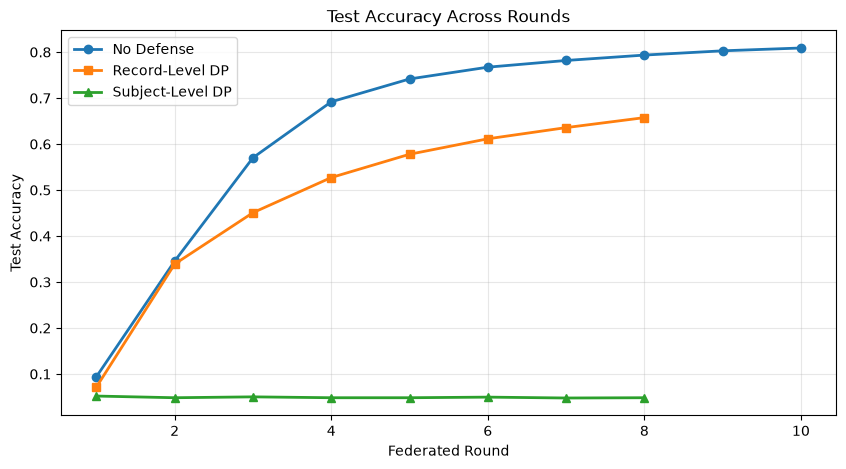

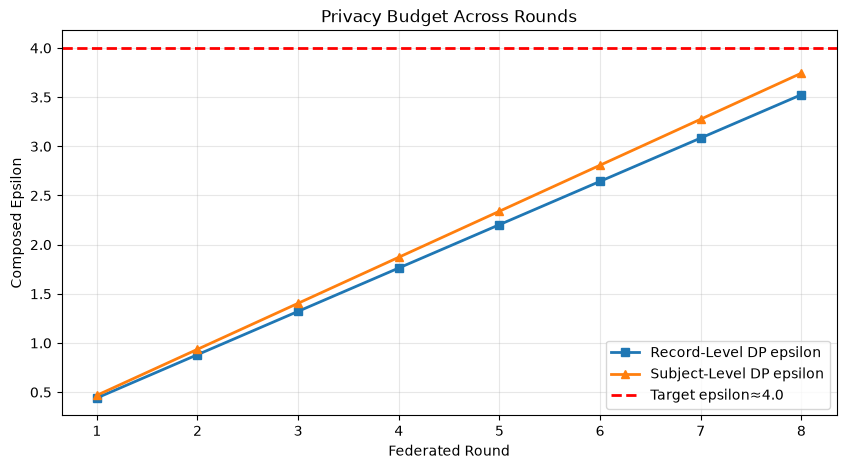

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(np.arange(1, len(round_test_accs) + 1), round_test_accs, marker="o", linewidth=2, label="No Defense")

if record_dp_result is not None:
    plt.plot(np.arange(1, len(record_dp_result["test_accs"]) + 1), record_dp_result["test_accs"], marker="s", linewidth=2, label="Record-Level DP")

plt.plot(np.arange(1, len(subject_dp_result["test_accs"]) + 1), subject_dp_result["test_accs"], marker="^", linewidth=2, label="Subject-Level DP")

plt.xlabel("Federated Round")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Across Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

if record_dp_result is not None:
    plt.plot(np.arange(1, len(record_dp_result["epsilons"]) + 1), record_dp_result["epsilons"], marker="s", linewidth=2, label="Record-Level DP epsilon")

plt.plot(np.arange(1, len(subject_dp_result["epsilons"]) + 1), subject_dp_result["epsilons"], marker="^", linewidth=2, label="Subject-Level DP epsilon")

plt.axhline(TARGET_EPSILON, linestyle="--", linewidth=2, color="red", label=f"Target epsilon≈{TARGET_EPSILON}")

plt.xlabel("Federated Round")
plt.ylabel("Composed Epsilon")
plt.title("Privacy Budget Across Rounds")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [35]:
sensitivity_rows = []

def add_sensitivity_result(defense_name, variant, result_obj, epsilon_note):
    sensitivity_rows.append({
        "Defense": defense_name,
        "Variant": variant,
        "Final_Test_Accuracy": result_obj["test_accs"][-1],
        "Final_Train_Accuracy": result_obj["train_accs"][-1],
        "Final_Epsilon": result_obj["epsilons"][-1],
        "Last_Round_Epsilon_Before_Composition": result_obj["round_epsilons"][-1],
        "Delta": TARGET_DELTA,
        "Noise_Multiplier": result_obj["noise_multiplier"],
        "Clip_Norm": result_obj["clip_norm"],
        "Rounds": len(result_obj["epsilons"]),
        "Epsilon_Note": epsilon_note
    })


print("\nSensitivity: Record-Level DP, Double Sigma")
rec_double_sigma = train_fedavg_record_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, noise_multiplier=2.0 * RECORD_DP_NOISE_MULT, max_grad_norm=RECORD_DP_CLIP_NORM, batch_size=DP_BATCH_SIZE)

add_sensitivity_result("Record-Level DP", "Double Sigma", rec_double_sigma, "Opacus per-local epsilon + conservative FL composition")

print("\nSensitivity: Record-Level DP, Half Clip Norm")
rec_half_clip = train_fedavg_record_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, noise_multiplier=RECORD_DP_NOISE_MULT, max_grad_norm=0.5 * RECORD_DP_CLIP_NORM, batch_size=DP_BATCH_SIZE)

add_sensitivity_result("Record-Level DP", "Half Clip Norm", rec_half_clip, "Opacus per-local epsilon + conservative FL composition")

print("\nSensitivity: Record-Level DP, Double Rounds")
rec_double_rounds = train_fedavg_record_dp(num_rounds=2 * DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, noise_multiplier=RECORD_DP_NOISE_MULT, max_grad_norm=RECORD_DP_CLIP_NORM, batch_size=DP_BATCH_SIZE)

add_sensitivity_result("Record-Level DP", "Double Rounds", rec_double_rounds, "Opacus per-local epsilon + conservative FL composition")

print("\nSensitivity: Subject-Level DP, Double Sigma")
sub_double_sigma = train_fedavg_subject_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, clip_norm=SUBJECT_DP_CLIP_NORM, noise_multiplier=2.0 * SUBJECT_DP_NOISE_MULT)

add_sensitivity_result("Subject-Level DP", "Double Sigma", sub_double_sigma, "Approximate subject-level epsilon + conservative FL composition")


print("\nSensitivity: Subject-Level DP, Half Clip Norm")
sub_half_clip = train_fedavg_subject_dp(num_rounds=DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, clip_norm=0.5 * SUBJECT_DP_CLIP_NORM, noise_multiplier=SUBJECT_DP_NOISE_MULT)

add_sensitivity_result("Subject-Level DP", "Half Clip Norm", sub_half_clip,"Approximate subject-level epsilon + conservative FL composition")


print("\nSensitivity: Subject-Level DP, Double Rounds")
sub_double_rounds = train_fedavg_subject_dp(num_rounds=2 * DP_NUM_ROUNDS, local_epochs=DP_LOCAL_EPOCHS, lr=DP_LR, clip_norm=SUBJECT_DP_CLIP_NORM, noise_multiplier=SUBJECT_DP_NOISE_MULT)

add_sensitivity_result("Subject-Level DP", "Double Rounds", sub_double_rounds, "Approximate subject-level epsilon + conservative FL composition")


sensitivity_df = pd.DataFrame(sensitivity_rows)

print("SENSITIVITY RESULTS")
display(sensitivity_df)



Sensitivity: Record-Level DP, Double Sigma


Record-Level DP Federated Training:   0%|          | 0/8 [00:00<?, ?it/s]

c:\Users\kamya\anaconda3\envs\new_env\Lib\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



Sensitivity: Record-Level DP, Half Clip Norm


Record-Level DP Federated Training:   0%|          | 0/8 [00:00<?, ?it/s]

...

Subject-Level DP Federated Training:   0%|          | 0/8 [00:00<?, ?it/s]


Sensitivity: Subject-Level DP, Double Rounds


Subject-Level DP Federated Training:   0%|          | 0/16 [00:00<?, ?it/s]

SENSITIVITY RESULTS


,Defense,Variant,Final_Test_Accuracy,Final_Train_Accuracy,Final_Epsilon,Last_Round_Epsilon_Before_Composition,Delta,Noise_Multiplier,Clip_Norm,Rounds,Epsilon_Note
0,Record-Level DP,Double Sigma,0.615568,0.618324,1.071113,0.133889,0.00001,2.0,1.0,8,Opacus per-local epsilon + conservative FL com...
1,Record-Level DP,Half Clip Norm,0.574794,0.576314,3.525268,0.440658,0.00001,1.0,0.5,8,Opacus per-local epsilon + conservative FL com...
2,Record-Level DP,Double Rounds,0.750883,0.753771,7.050536,0.440658,0.00001,1.0,1.0,16,Opacus per-local epsilon + conservative FL com...
3,Subject-Level DP,Double Sigma,0.029391,0.029954,1.872040,0.234005,0.00001,2.4,1.0,8,Approximate subject-level epsilon + conservati...
4,Subject-Level DP,Half Clip Norm,0.055022,0.054808,3.744080,0.468010,0.00001,1.2,0.5,8,Approximate subject-level epsilon + conservati...
5,Subject-Level DP,Double Rounds,0.049690,0.050774,7.488160,0.468010,0.00001,1.2,1.0,16,Approximate subject-level epsilon + conservati...


In [36]:
final_tables = [make_no_defense_summary()]

if record_dp_summary is not None:
    final_tables.append(record_dp_summary)

final_tables.append(subject_dp_summary)

tradeoff_df = pd.concat(final_tables, ignore_index=True)

print("FINAL TRADE-OFF TABLE")
display(tradeoff_df)

FINAL TRADE-OFF TABLE


,Defense,Final_Test_Accuracy,Final_Train_Accuracy,Epsilon,Delta,Noise_Multiplier,Clip_Norm,Subject_F1,Subject_AUC,Record_F1,Record_AUC,Epsilon_Note
0,No Defense,0.808865,0.811260,NaN,NaN,0.0,NaN,0.498148,0.510731,0.500760,0.500687,No DP mechanism
1,Record-Level DP,0.657458,0.659434,3.525268,0.00001,1.0,1.0,0.482407,0.490977,0.501642,0.500891,Opacus per-local epsilon + conservative compos...
2,Subject-Level DP,0.048372,0.048725,3.744080,0.00001,1.2,1.0,0.494444,0.497496,0.515421,0.501754,Approximate subject-level epsilon + conservati...
